In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from math import radians, cos, sin
import pandas as pd
import astropy as ap
import fitsio as fi
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.patches import Ellipse
from astropy.io import fits
from astropy.wcs import WCS
import Lib_Alma as alma

In [2]:
import warnings
warnings.filterwarnings("ignore")
n=0.5
m=0.5
cat_A=alma.read_txt(alma.catalogue_name('7M'))
f_clump,f_id,ob_clump,ob_id,oc_clump,oc_id=alma.family_tree(n,m,20,20)
clump_stat_A=alma.multiplicity_stat_A_B(f_clump,cat_A)
clump_stat_B=alma.multiplicity_stat_B_C(f_clump,ob_clump,cat_A)

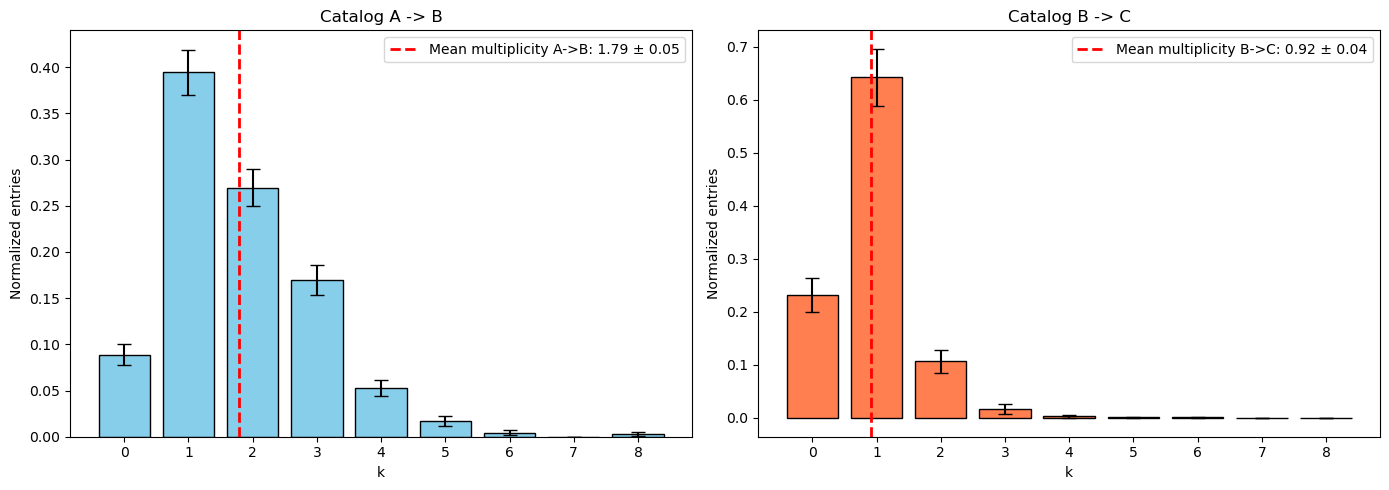

1.7921348314606742 0.9210379464285714


In [3]:
alma.mult_distribution(clump_stat_A,clump_stat_B)


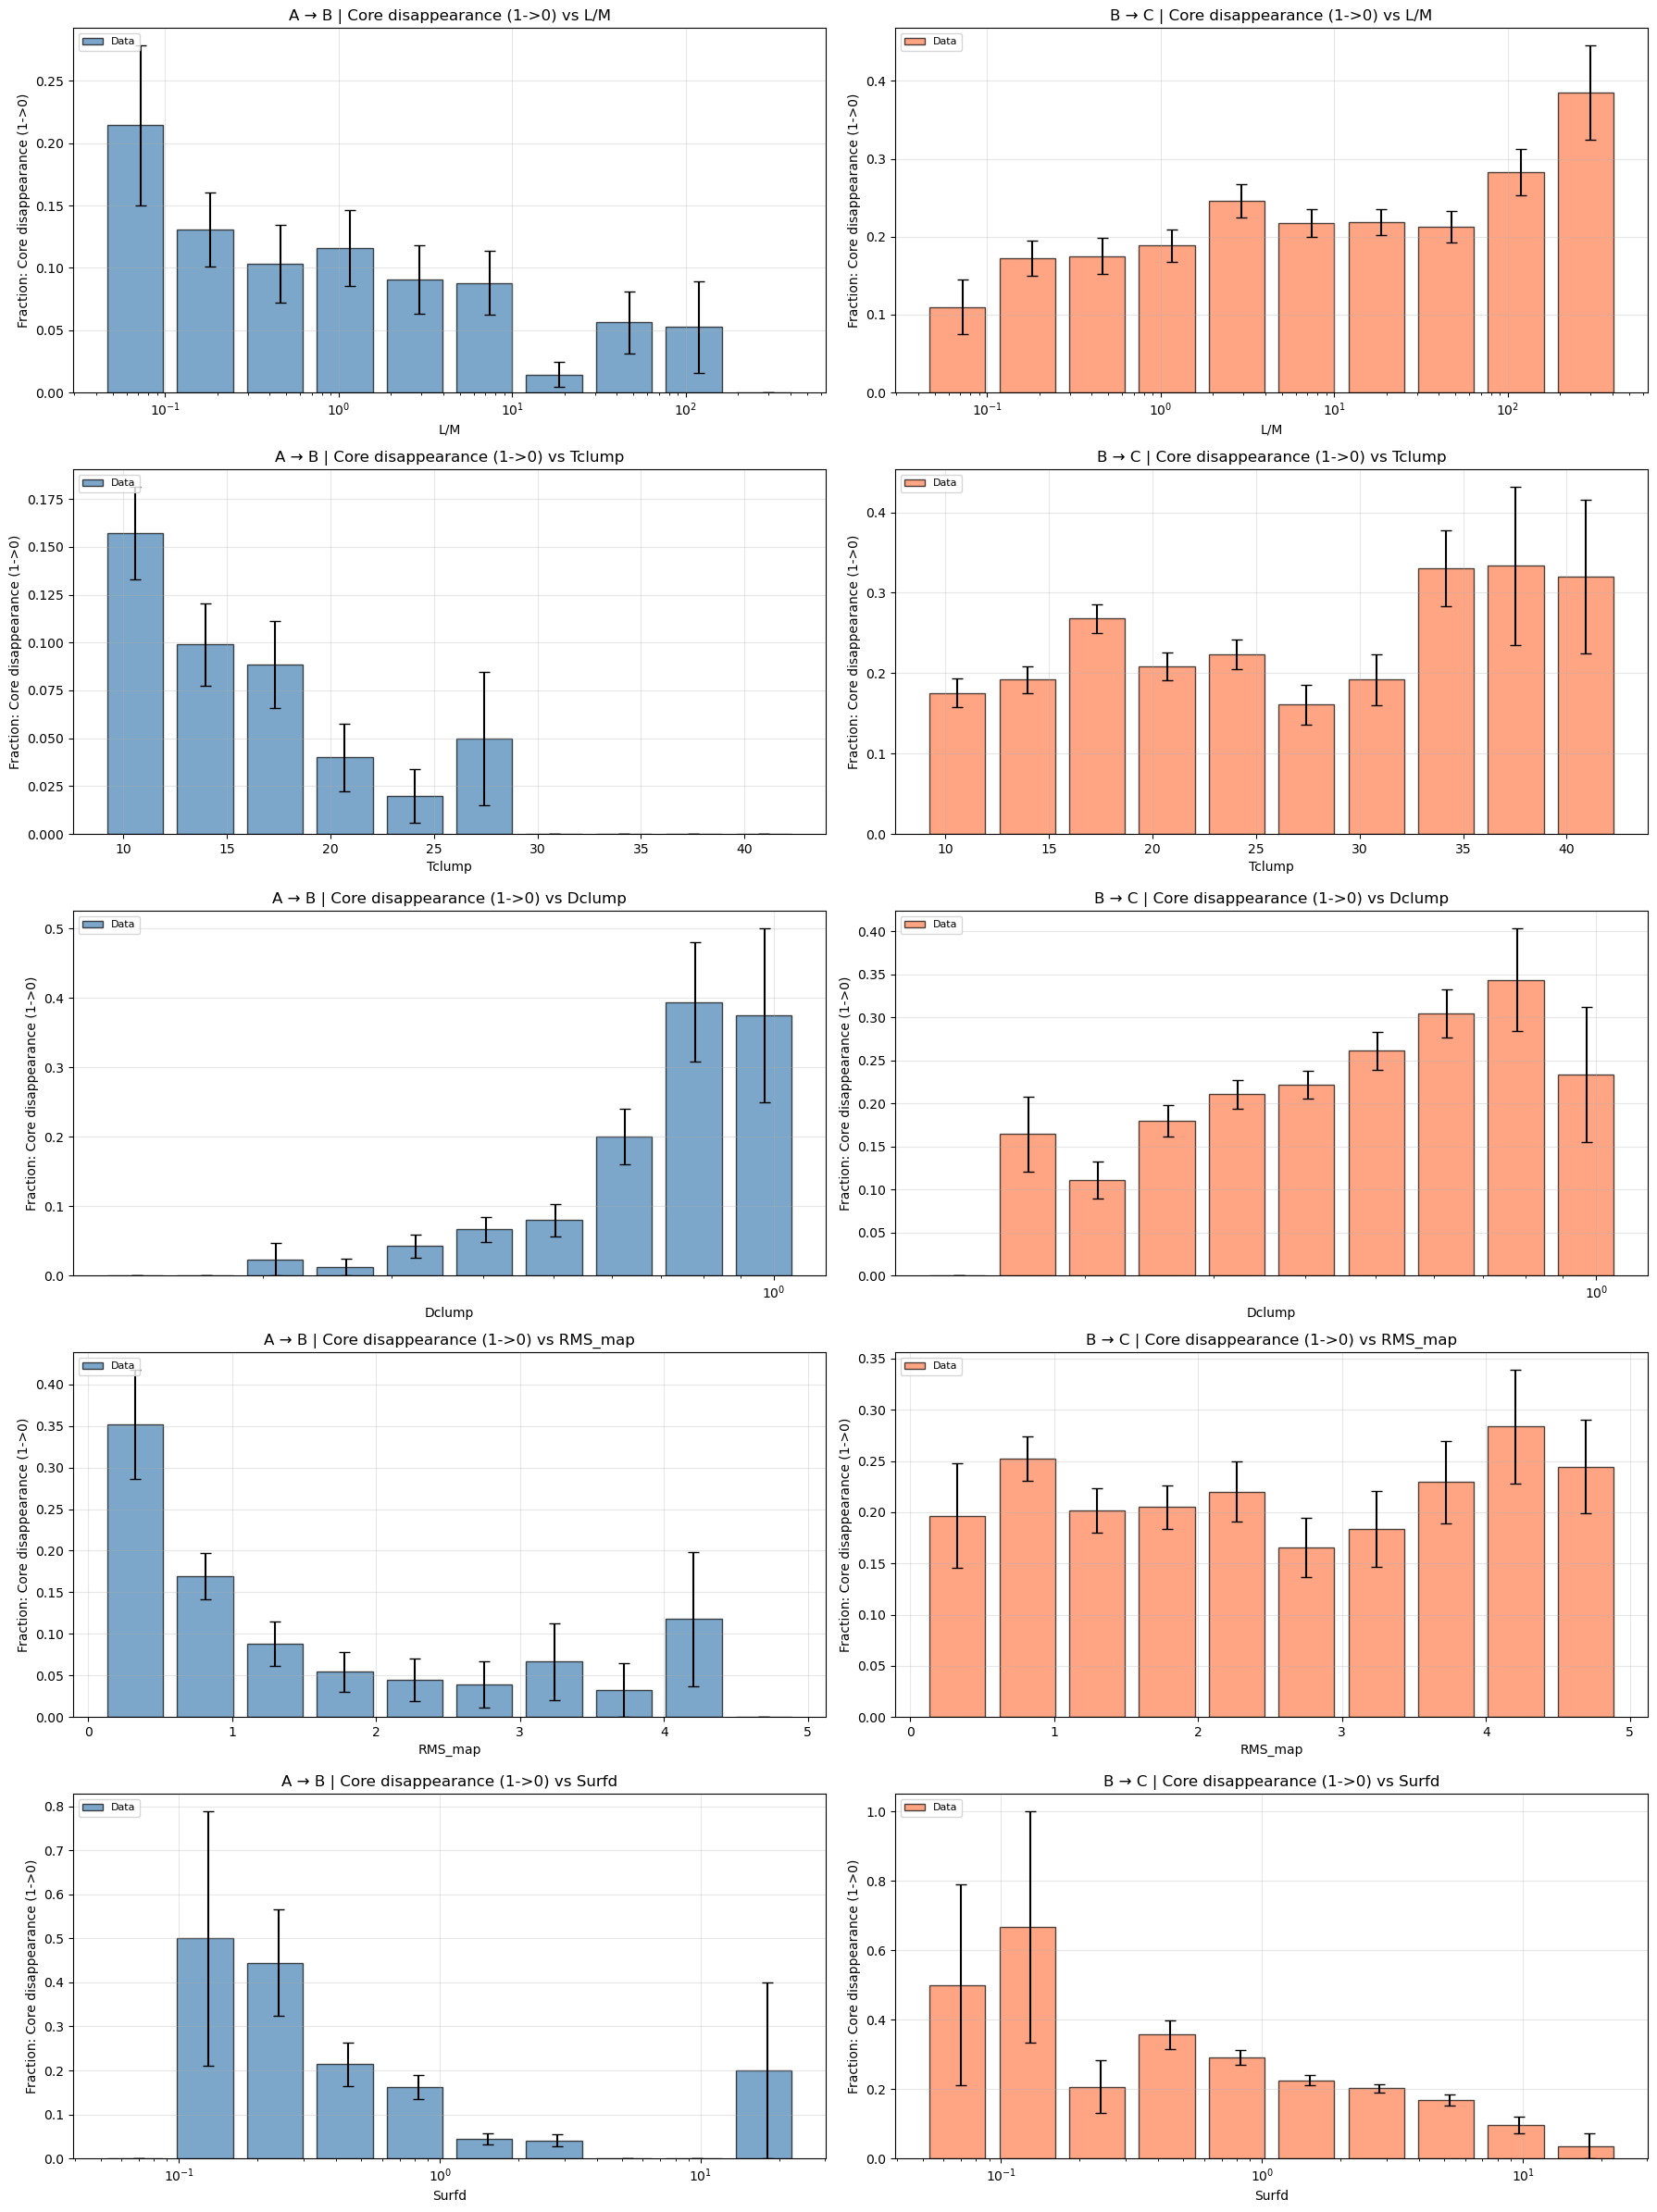


Total AB clumps: 763
Total BC clumps: 896

Multiplicity selected: 1->0 (Core disappearance (1->0))


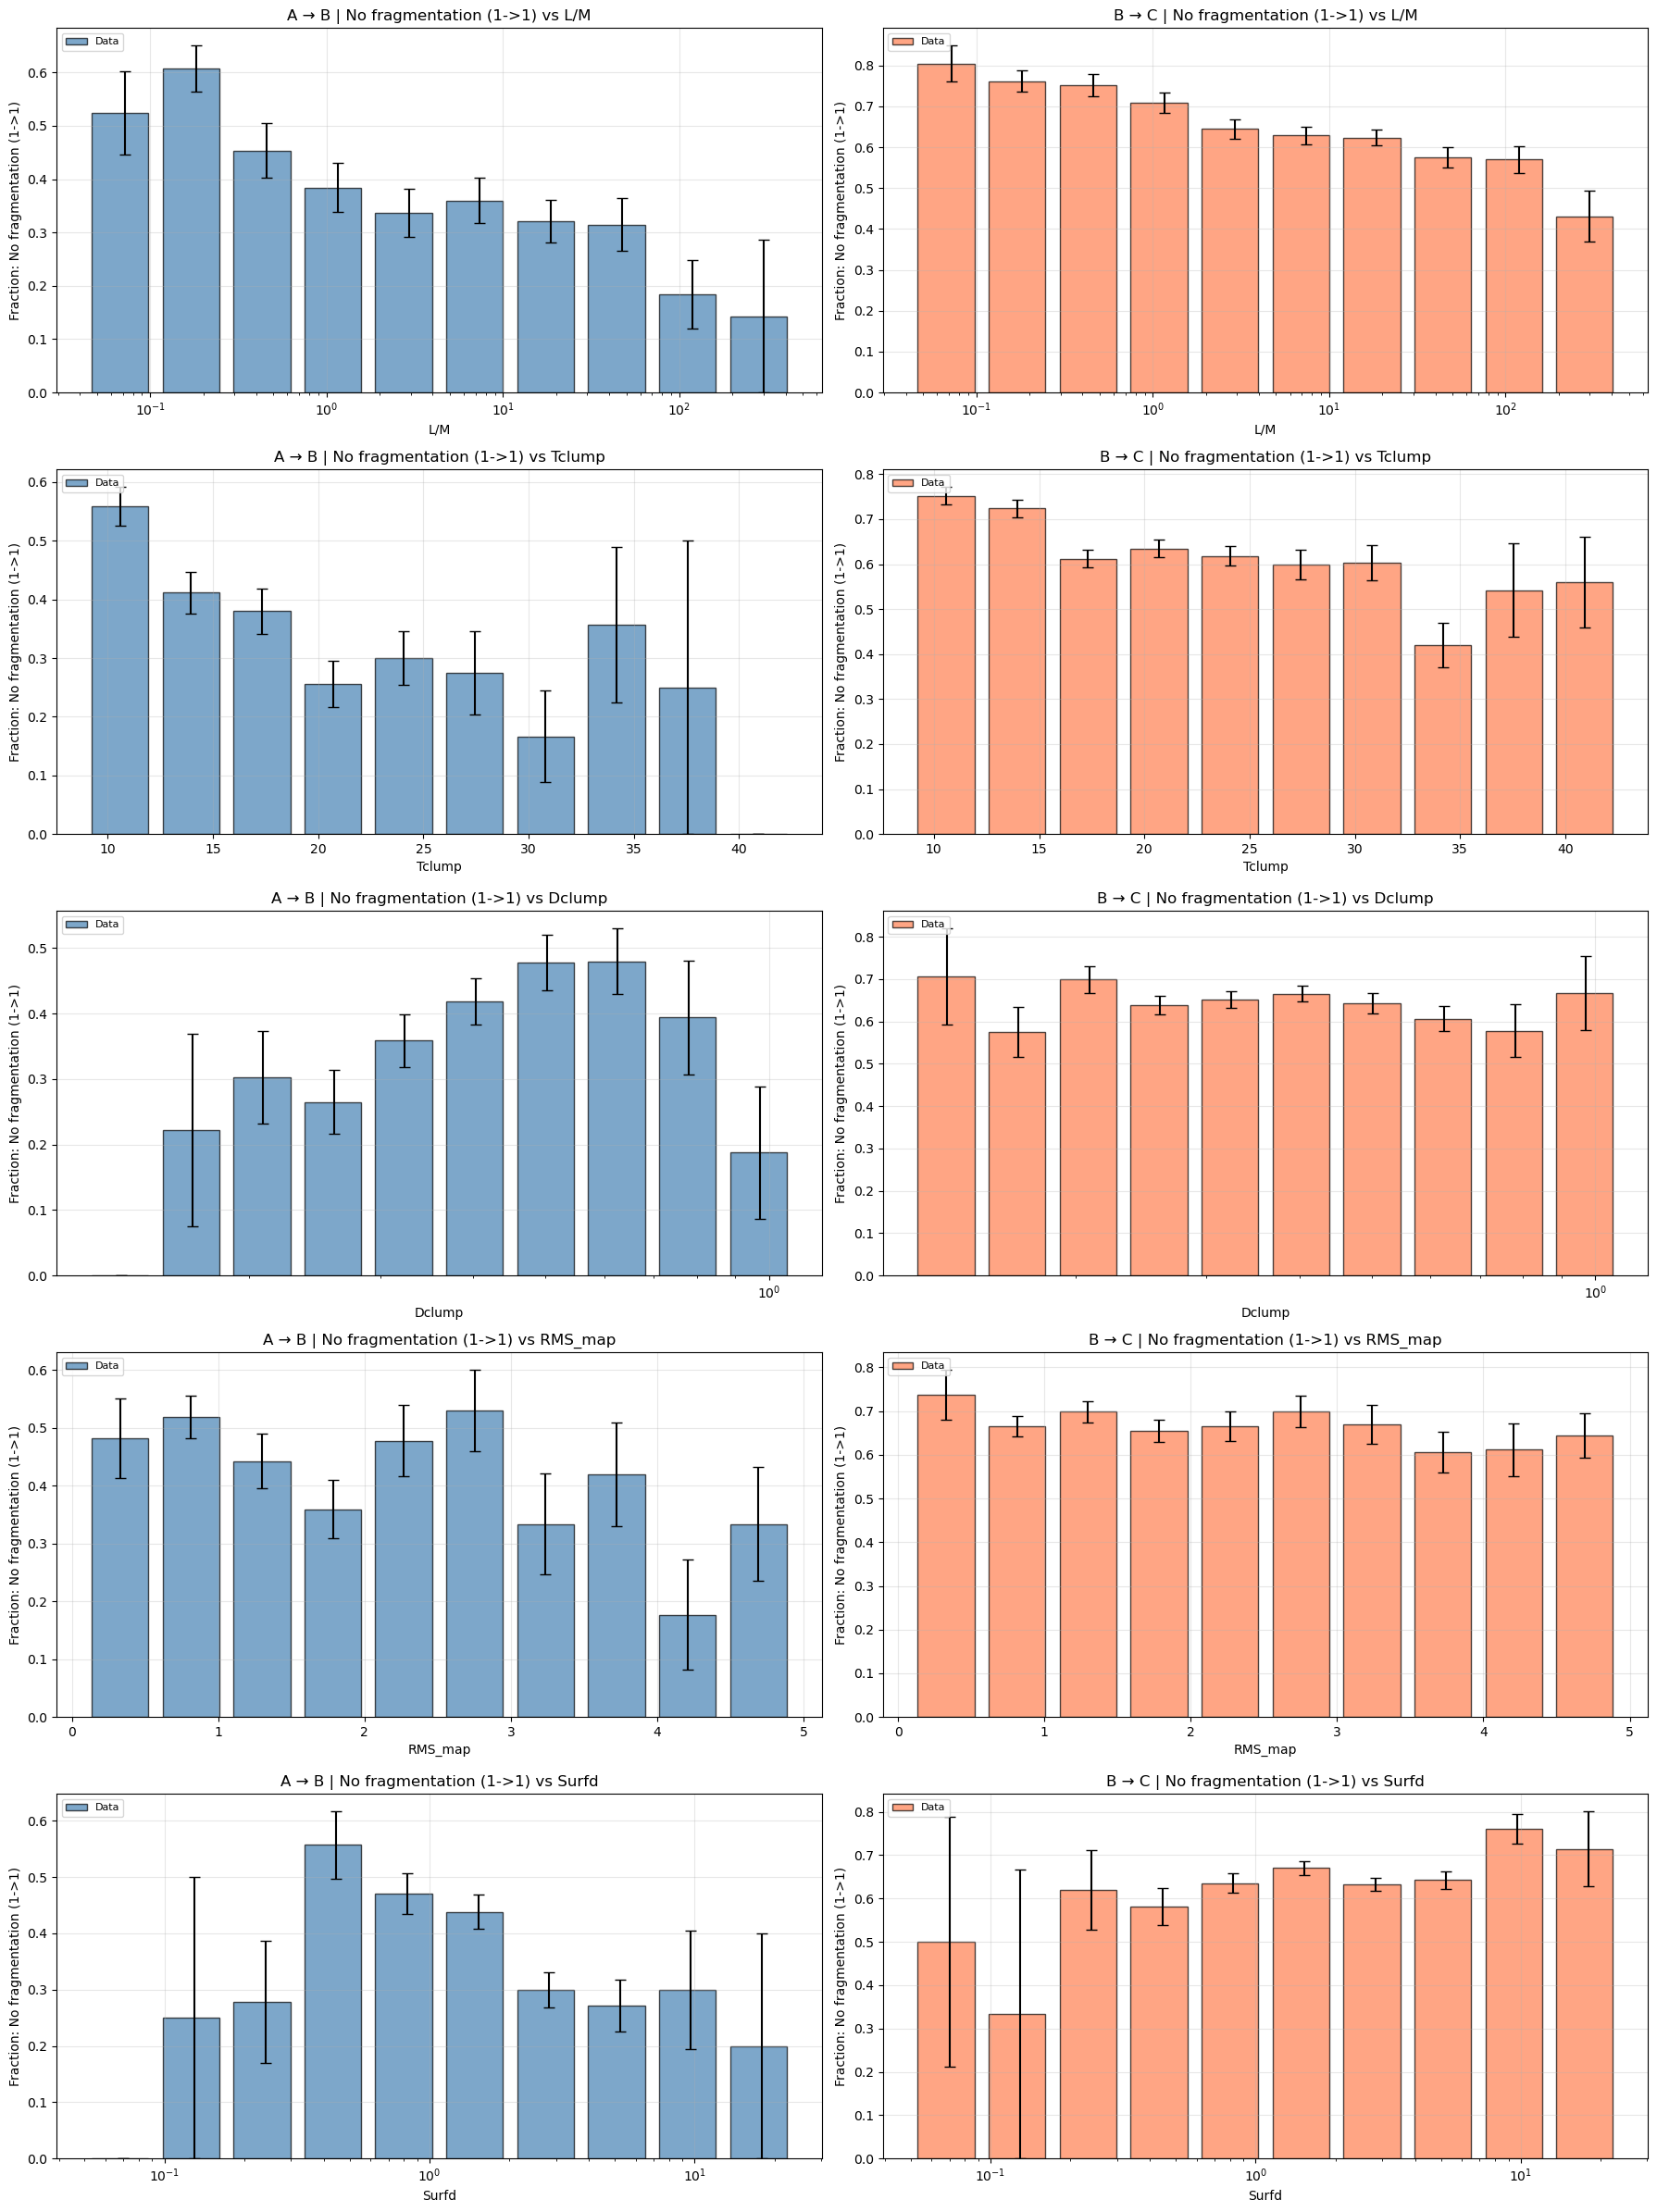


Total AB clumps: 763
Total BC clumps: 896

Multiplicity selected: 1->1 (No fragmentation (1->1))


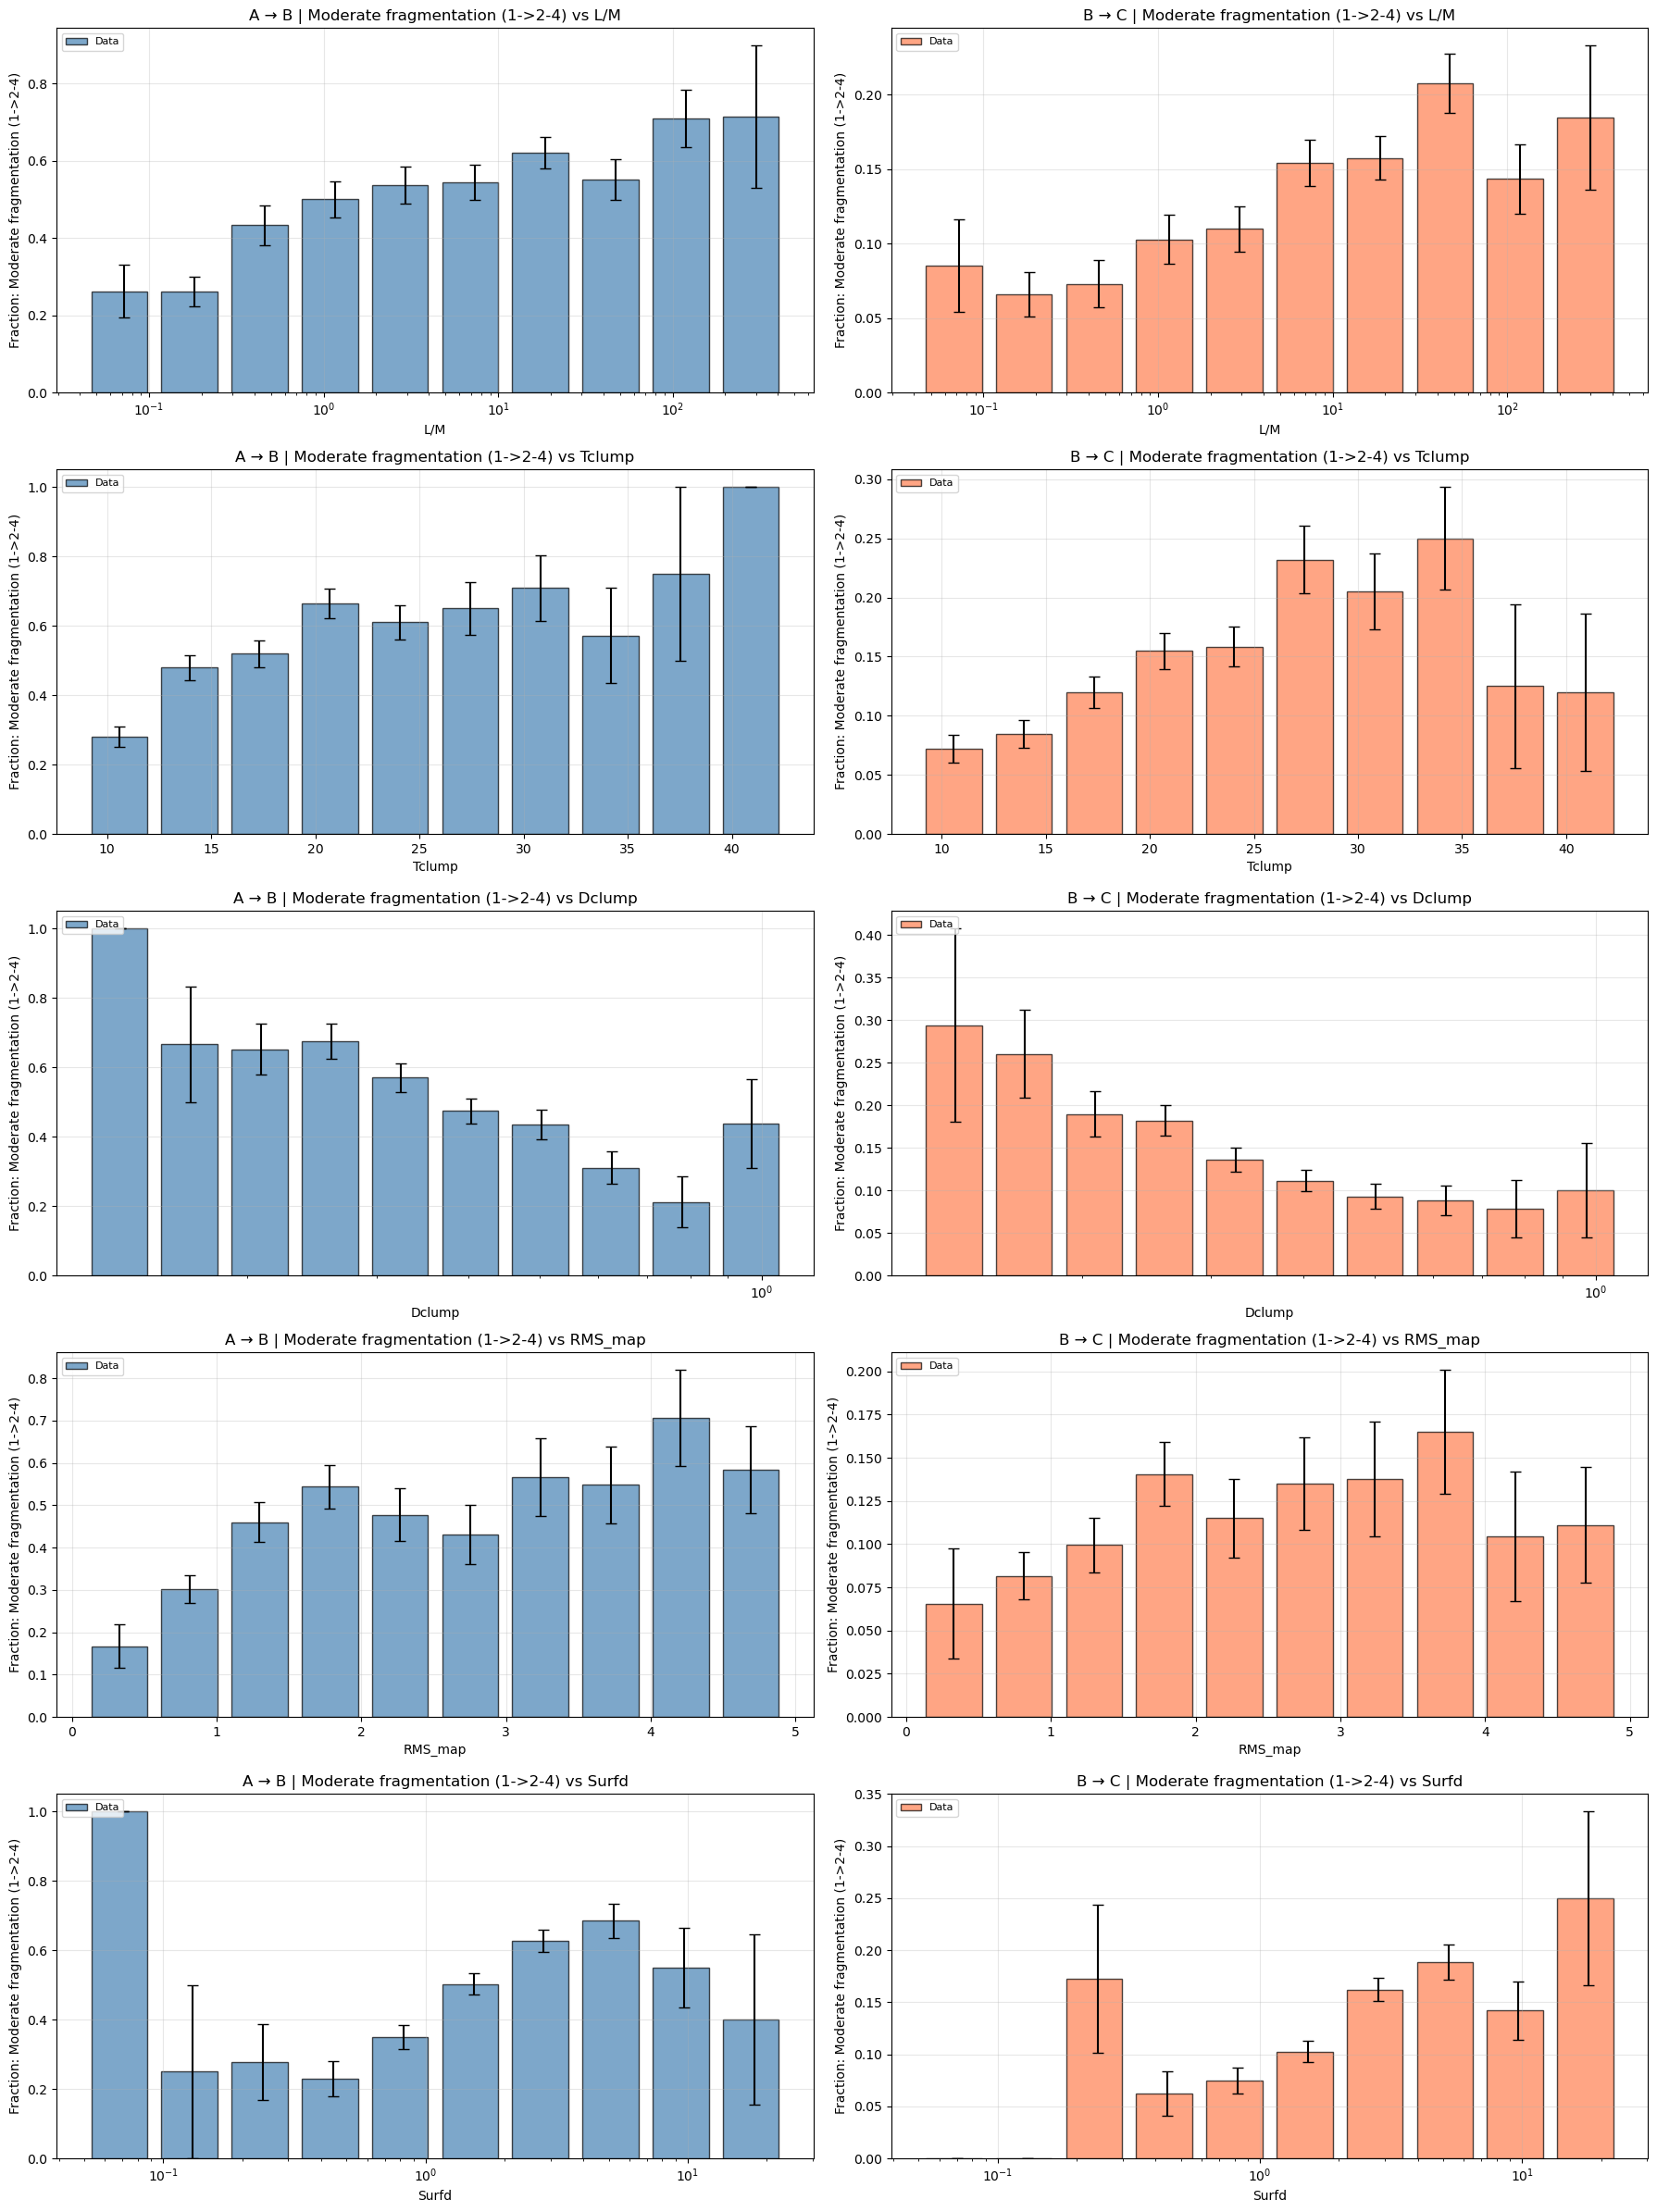


Total AB clumps: 763
Total BC clumps: 896

Multiplicity selected: 1->2-4 (Moderate fragmentation (1->2-4))


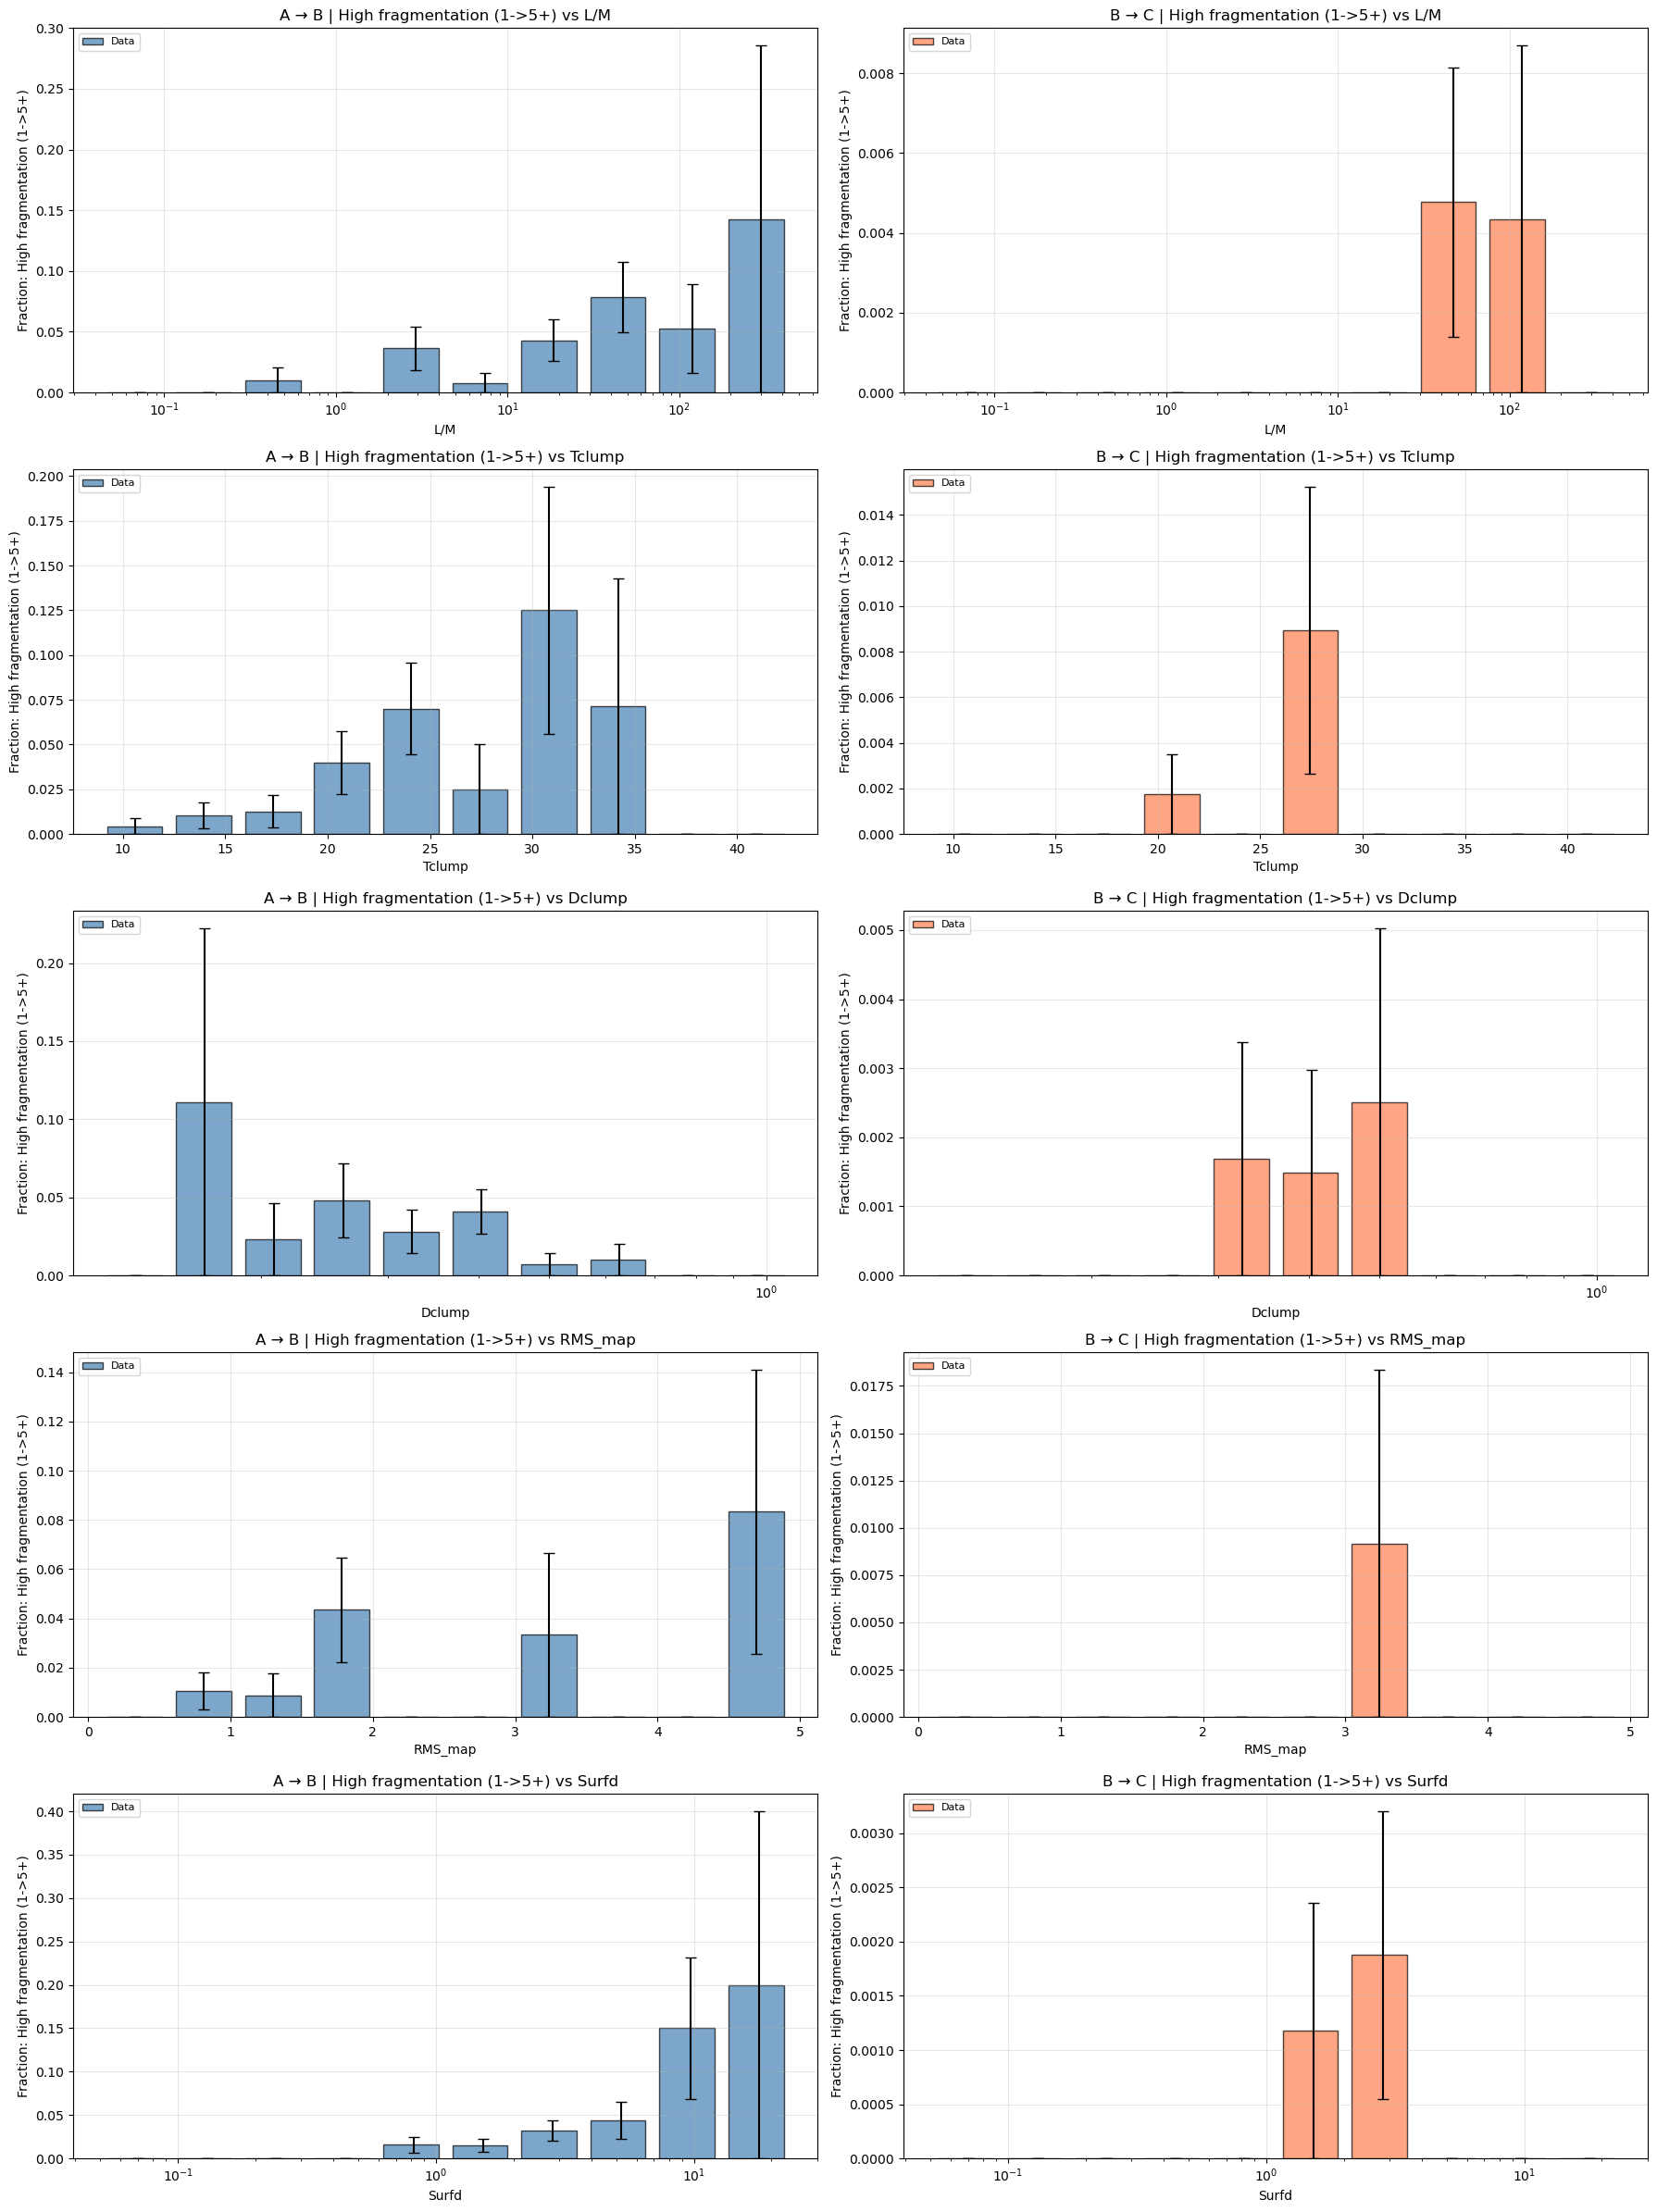


Total AB clumps: 763
Total BC clumps: 896

Multiplicity selected: 1->5+ (High fragmentation (1->5+))


In [4]:
alma.plot_multiplicity_vs_properties_log_with_fit(clump_stat_A, clump_stat_B, multiplicity='1->0',run_fit=False)
alma.plot_multiplicity_vs_properties_log_with_fit(clump_stat_A, clump_stat_B, multiplicity='1->1',run_fit=False)
alma.plot_multiplicity_vs_properties_log_with_fit(clump_stat_A, clump_stat_B, multiplicity='1->2-4',run_fit=False)
alma.plot_multiplicity_vs_properties_log_with_fit(clump_stat_A, clump_stat_B, multiplicity='1->5+',run_fit=False)

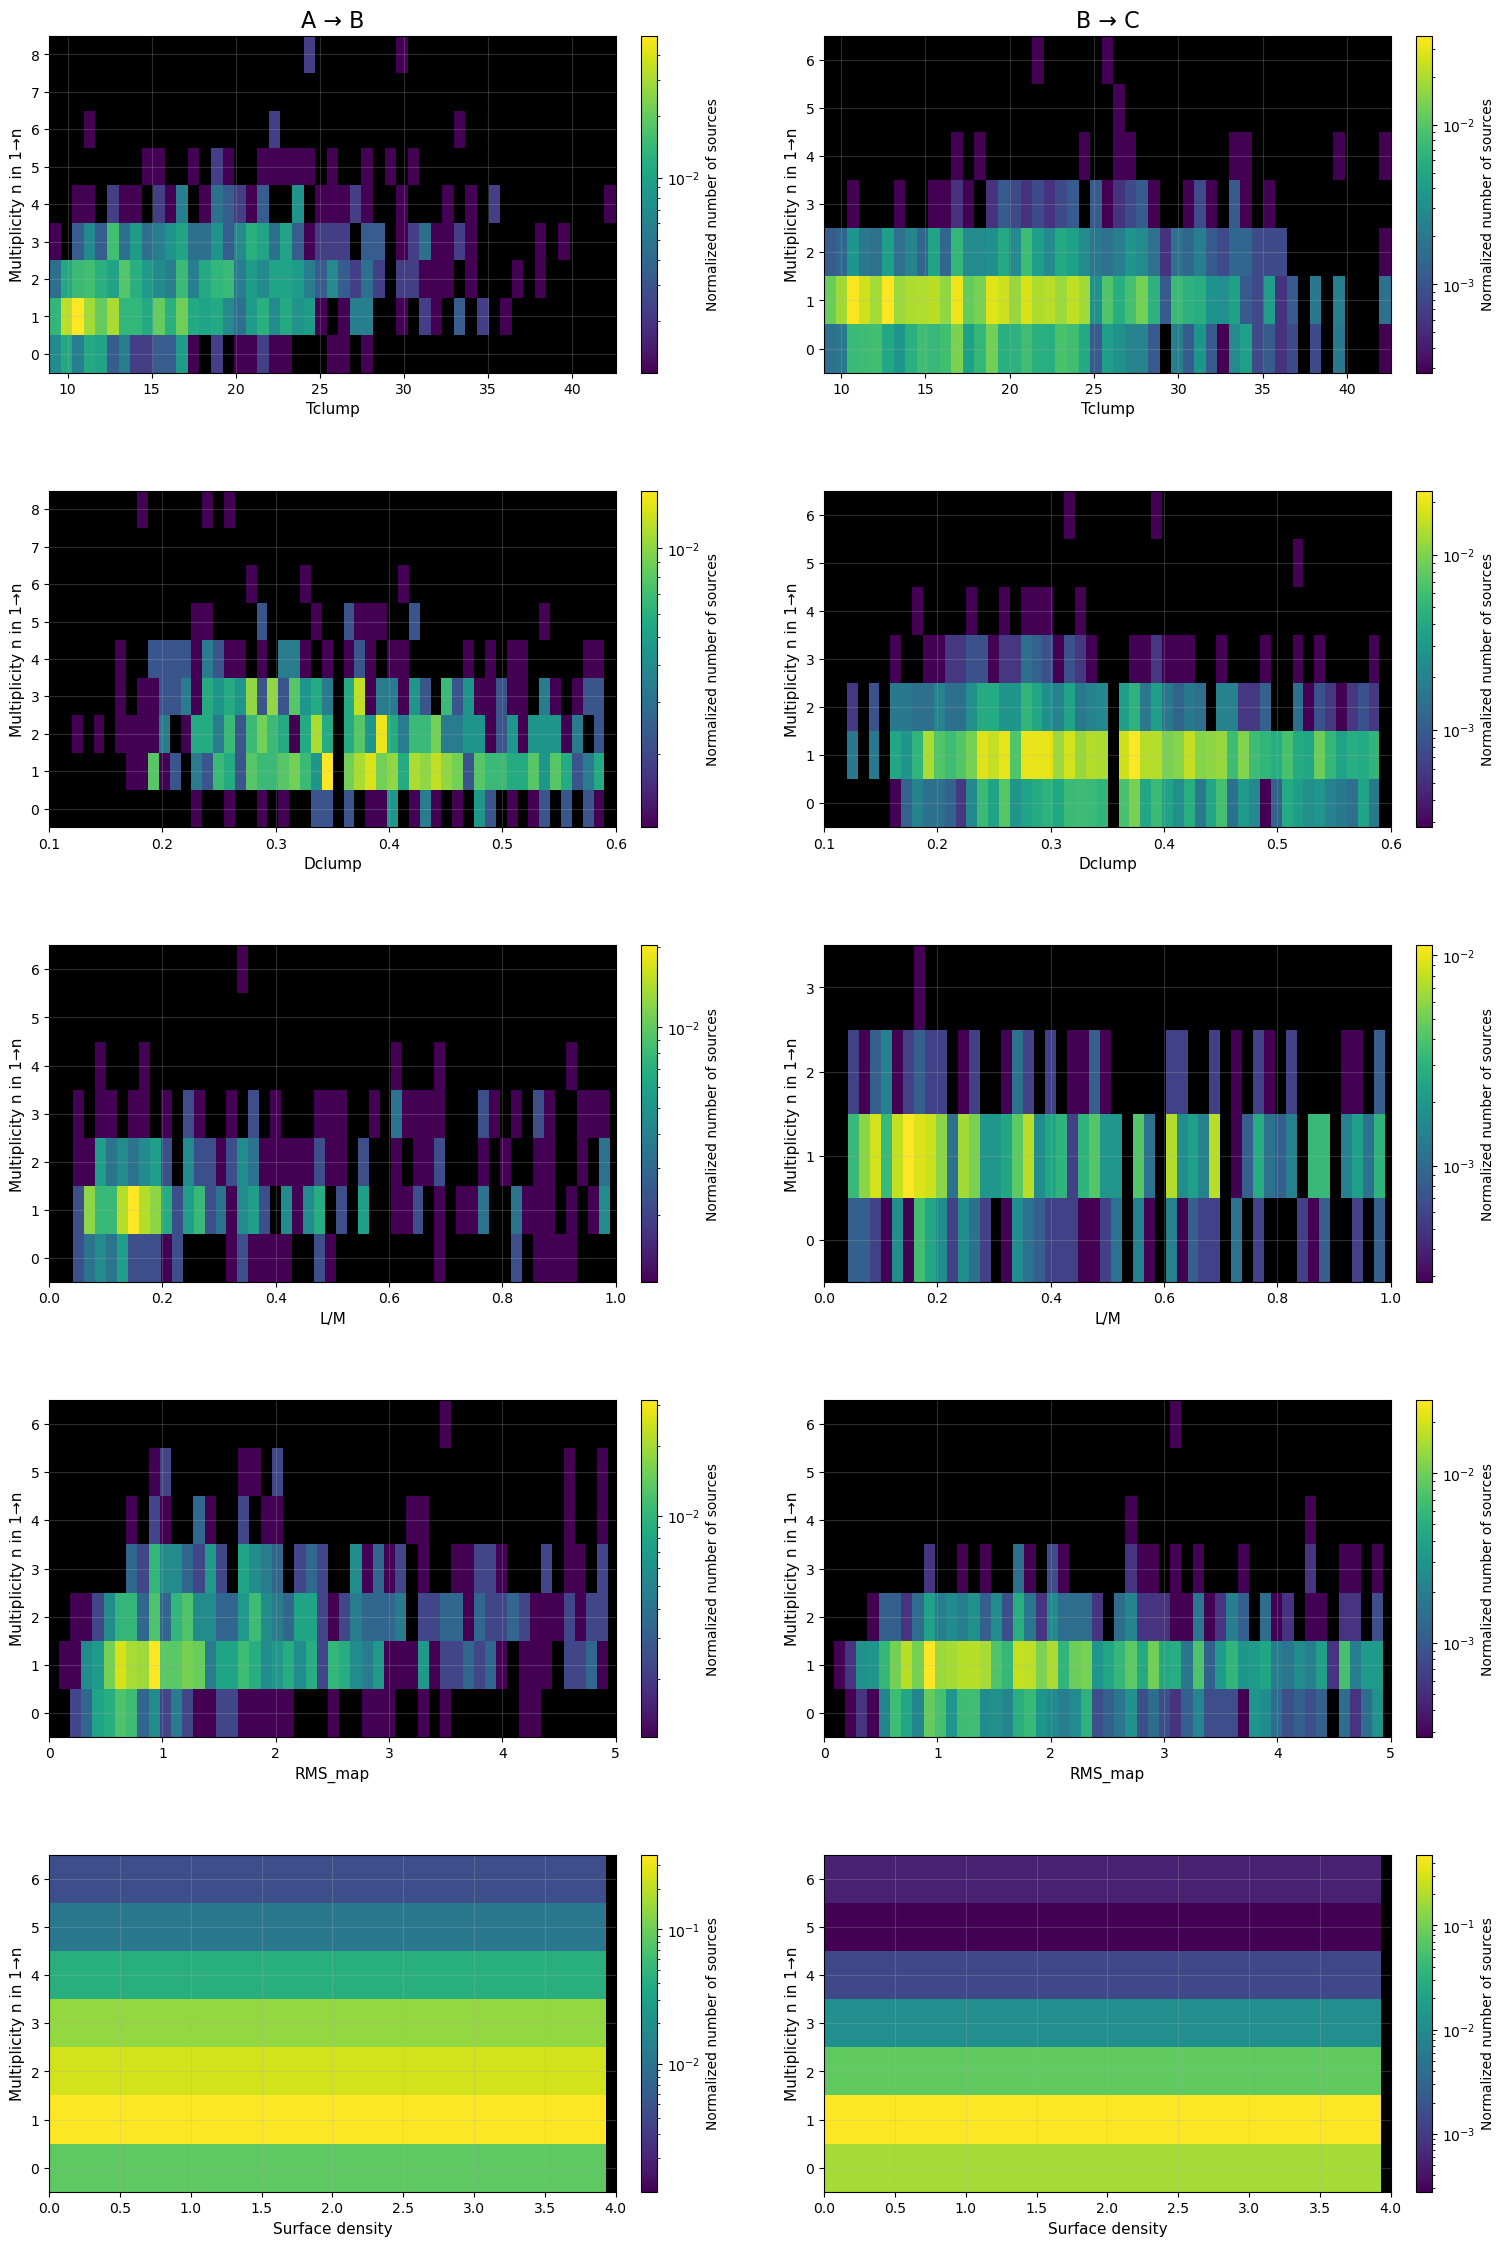

In [5]:
alma.joint_pdf_mult_prop(clump_stat_A, clump_stat_B)

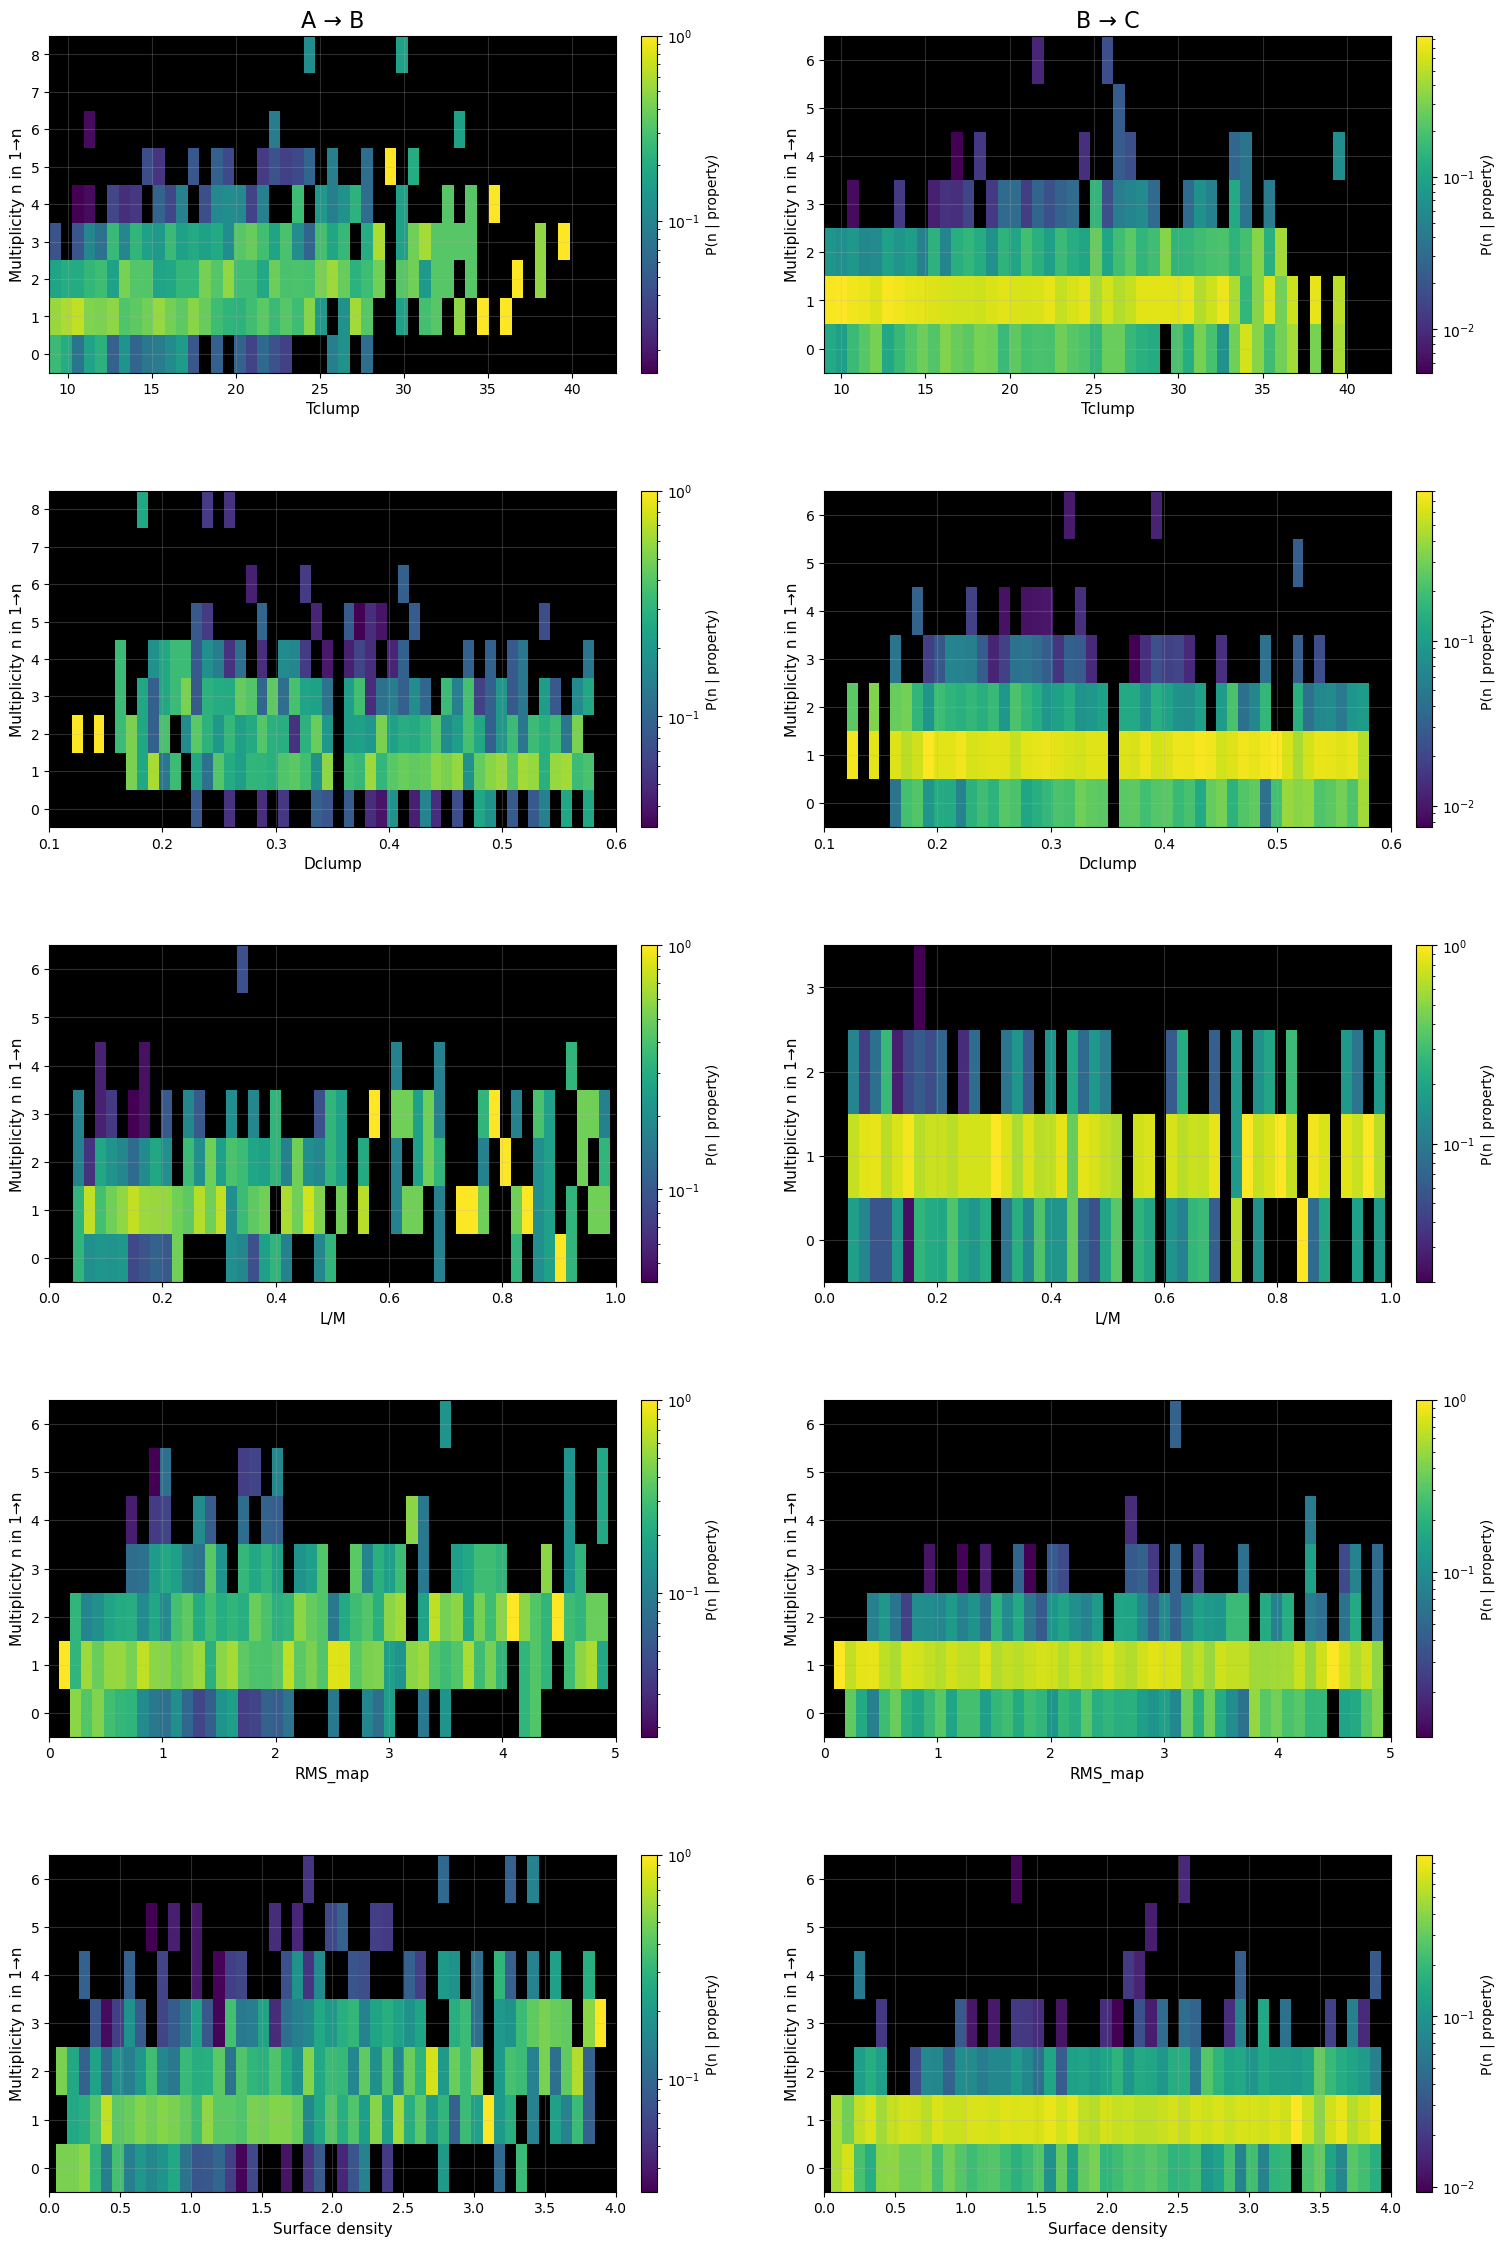

In [6]:
alma.conditional_pdf_mult_prop(clump_stat_A,clump_stat_B)


Generazione report per 763 clumps...

[1/763]   0.1%  CLUMP: 100132   Tempo:    0.1s


KeyboardInterrupt: 

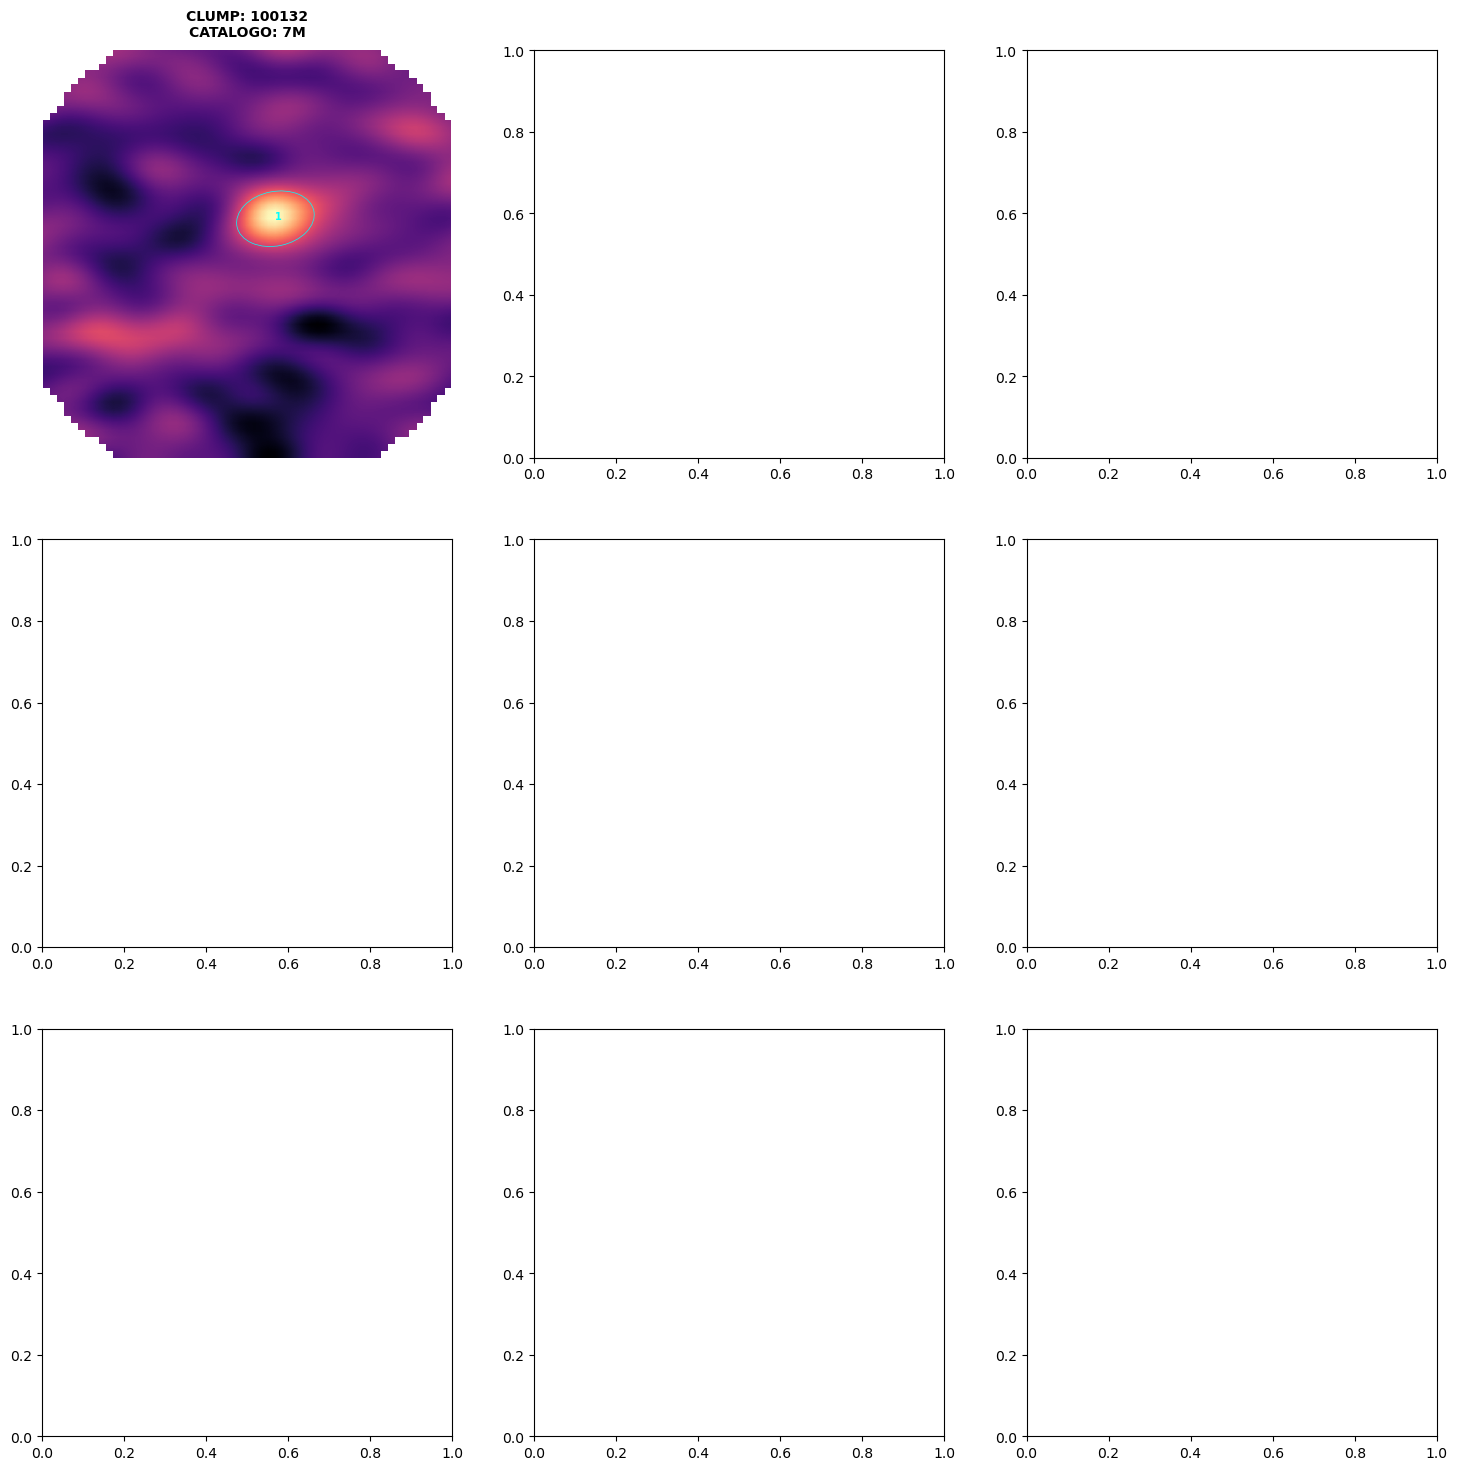

: 

In [ ]:
cat_A=alma.read_txt(alma.catalogue_name('7M'))
cat_B=alma.read_txt(alma.catalogue_name('7MTM2'))
cat_C=alma.read_txt(alma.catalogue_name('7MTM2TM1'))
N=10
filename=f'report_clumps_n_{n}_clumps_{N}.pdf'
alma.genera_report_clumps_finale_proj(filename,f_clump,f_id,ob_clump,ob_id,oc_clump,oc_id,cat_A,cat_B,cat_C)



In [40]:
def mult_distribution(clump_stat_A, clump_stat_B):

    N = 9

    n = np.zeros(N)
    m = np.zeros(N)
    N_sources_A = len(clump_stat_A['CLUMP'])
    N_sources_B = len(clump_stat_B['CLUMP'])

    # Conteggio per catalogo A
    for i in range(len(clump_stat_A['CLUMP'])):
        for k in range(N):
            if f'1->{k}' in clump_stat_A['mult_stat'][i]:
                n[k] += clump_stat_A['mult_stat'][i][f'1->{k}']

    # Conteggio per catalogo B
    for i in range(len(clump_stat_B['CLUMP'])):
        for k in range(N):
            if f'1->{k}' in clump_stat_B['mult_stat'][i]:
                m[k] += clump_stat_B['mult_stat'][i][f'1->{k}']

    x = np.arange(0, N, 1)

    mean_n = np.dot(n, x) / np.sum(n)
    mean_m = np.dot(m, x) / np.sum(m)

    err_mean=0
    for i in range(len(clump_stat_A['CLUMP'])):
        for k in range(N):
            if f'1->{k}' in clump_stat_A['mult_stat'][i]:
                err_mean += clump_stat_A['mult_stat'][i][f'1->{k}'] * (k - mean_n) ** 2
    err_mean_n = np.sqrt(err_mean / N_sources_A) / np.sqrt(N_sources_A)
    err_mean=0
    for i in range(len(clump_stat_B['CLUMP'])):
        for k in range(N):
            if f'1->{k}' in clump_stat_B['mult_stat'][i]:
                err_mean += clump_stat_B['mult_stat'][i][f'1->{k}'] * (k - mean_m) ** 2
    err_mean_m = np.sqrt(err_mean / N_sources_B) / np.sqrt(N_sources_B)

    # =========================
    # Errori poissoniani
    # =========================

    err_n = np.sqrt(n)
    err_m = np.sqrt(m)

    # Errori sulle quantità normalizzate
    err_n_norm = err_n / N_sources_A
    err_m_norm = err_m / N_sources_B

    # =========================
    # Plot
    # =========================

    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    # --- PRIMO GRAFICO (Catalogo A) ---

    ax[0].bar(
        x,
        n / np.sum(n),
        yerr=err_n_norm,
        capsize=5,
        color='skyblue',
        edgecolor='black',
        width=0.8
    )

    ax[0].axvline(
        mean_n,
        color='red',
        linestyle='--',
        linewidth=2,
        label=f'Mean multiplicity A->B: {mean_n:.2f} ± {err_mean_n:.2f}'
    )

    ax[0].set_xticks(x)
    ax[0].set_xlabel('k')
    ax[0].set_ylabel('Normalized entries')
    ax[0].set_title('Catalog A -> B')
    ax[0].legend()

    # --- SECONDO GRAFICO (Catalogo B) ---

    ax[1].bar(
        x,
        m / np.sum(m),
        yerr=err_m_norm,
        capsize=5,
        color='coral',
        edgecolor='black',
        width=0.8
    )

    ax[1].axvline(
        mean_m,
        color='red',
        linestyle='--',
        linewidth=2,
        label=f'Mean multiplicity B->C: {mean_m:.2f} ± {err_mean_m:.2f}'
    )

    ax[1].set_xticks(x)
    ax[1].set_xlabel('k')
    ax[1].set_ylabel('Normalized entries')
    ax[1].set_title('Catalog B -> C')
    ax[1].legend()
    plt.tight_layout()
    plt.show()

    print(mean_n, mean_m)

    return

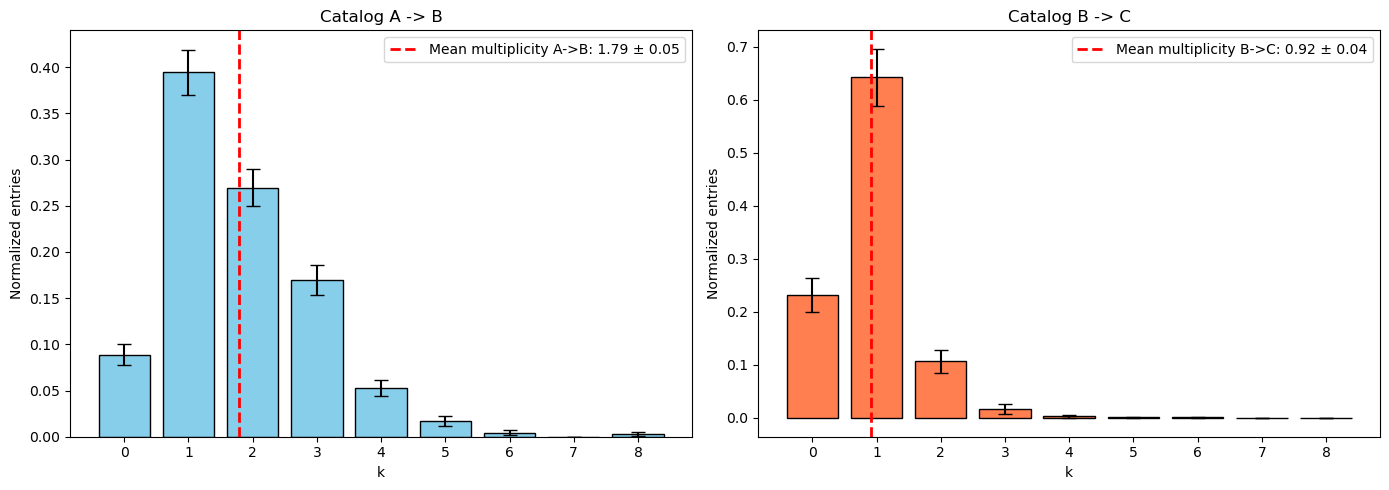

1.7921348314606742 0.9210379464285714


In [41]:
mult_distribution(clump_stat_A, clump_stat_B)